In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [6]:
filename = 'HealthApp_2k.log'

# simpan ekstraksi ke list
data_list = []

# regex
# \d{8}       -> Tanggal (8 digit)
# \d{1,2}     -> Jam, Menit, Detik (Bisa 1 atau 2 digit, ini kuncinya!)
# REPORT :    -> Kata kunci pemisah
# (\d+)       -> Menangkap angka langkah (Total Steps)
log_pattern = re.compile(r'^(\d{8}-\d{1,2}:\d{1,2}:\d{1,2}:\d{3}).*REPORT : (\d+)')

In [7]:
with open(filename, 'r') as file:
    for line in file:
        match = log_pattern.search(line)
        if match:
            timestamp_str = match.group(1)
            steps = int(match.group(2))
            data_list.append({'timestamp_raw': timestamp_str, 'steps': steps})

cleaning dataframe

In [8]:
if len(data_list) > 0:
    df = pd.DataFrame(data_list)

    # konversi string ke datetime
    df['timestamp'] = pd.to_datetime(df['timestamp_raw'], format='%Y%m%d-%H:%M:%S:%f')

    df = df.drop(columns=['timestamp_raw'])
    df = df.sort_values('timestamp')

    # RESAMPLING
    # set index menjadi waktu
    df = df.set_index('timestamp')

    # Resample tiap 1 menit.
    # jika tidak ada log di menit 'x', otomatis jadi NaN (kosong), agar data jujur.
    df_clean = df.resample('1min').max().reset_index()

    print(f"data berhasil diproses")
    print(f"jumlah baris data bersih: {len(df_clean)}")
    print("\n cek 5 data tail agar memastikan sudah masuk tanggal 24: ")
    print(df_clean.tail()) # Harus menampilkan tanggal 2017-12-24
else:
    print("Tidak ada data yang cocok dengan pola Regex.")

data berhasil diproses
jumlah baris data bersih: 106

 cek 5 data tail agar memastikan sudah masuk tanggal 24: 
              timestamp  steps
101 2017-12-23 23:56:00    NaN
102 2017-12-23 23:57:00    NaN
103 2017-12-23 23:58:00    NaN
104 2017-12-23 23:59:00    NaN
105 2017-12-24 00:00:00    0.0


# Fishualization

## Visualisasi langkah kaki penggunaan aplikasi

In [9]:
import matplotlib.dates as mdates

In [10]:
# 1. mendeteksi steps yang tereset 
df_clean['diff_calc'] = df_clean['steps'].ffill().diff()
reset_events = df_clean[df_clean['diff_calc'] < -1000]

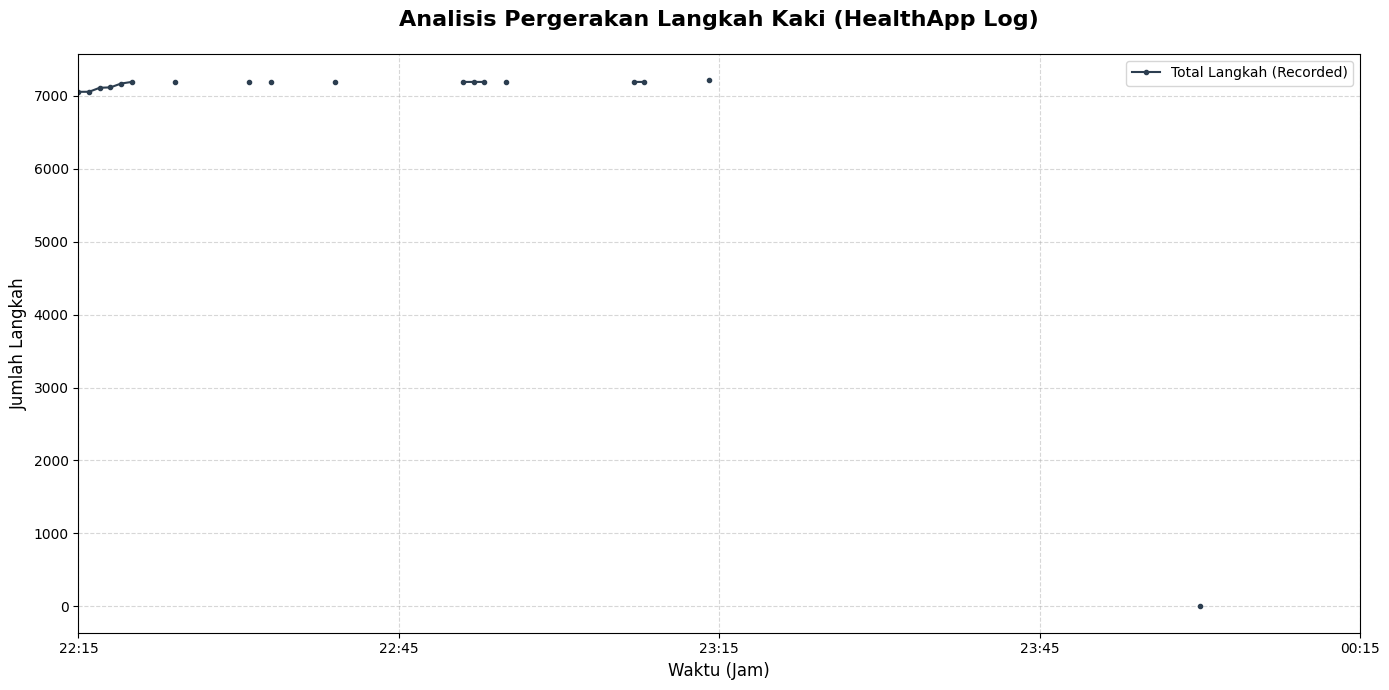

In [23]:
# 2. setup grafik
fig, ax = plt.subplots(figsize=(14, 7))

# plot datanya
ax.plot(df_clean['timestamp'], df_clean['steps'],
        color='#2c3e50', linewidth=1.5,
        marker='o', markersize=3, label='Total Langkah (Recorded)')

# 3. buat anotasi
if not reset_events.empty:
    reset_time = reset_events.iloc[0]['timestamp']
    idx_reset = reset_events.index[0]
    
    # Logika mencari titik puncak sebelum jatuh
    prev_data = df_clean.loc[idx_reset-10:idx_reset-1].dropna()
    
    if not prev_data.empty:
        val_before = prev_data.iloc[-1]['steps']
        time_before = prev_data.iloc[-1]['timestamp']

        ax.annotate('Midnight Reset\n(System Logic)',
                    xy=(mdates.date2num(time_before), val_before),
                    xytext=(mdates.date2num(time_before) - 0.08, val_before - 2500),
                    arrowprops=dict(facecolor='#c0392b', shrink=0.05, width=2),
                    fontsize=11, color='#c0392b', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#c0392b", alpha=0.9))
        
        print(f"📍 Anotasi ditambahkan menunjuk ke: {time_before}")

# fish
ax.set_title('Analisis Pergerakan Langkah Kaki (HealthApp Log)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Waktu (Jam)', fontsize=12)
ax.set_ylabel('Jumlah Langkah', fontsize=12)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

# memaksa batas sumbu X agar data reset terlihat dengan jelas
end_limit = df_clean['timestamp'].max() + pd.Timedelta(minutes=15)
ax.set_xlim(df_clean['timestamp'].min(), end_limit)

ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('analisis_pergerakan_langkah_kaki.png', dpi=300, bbox_inches='tight')
plt.show()

## Zoom detail: Transisi data pukul 00:00

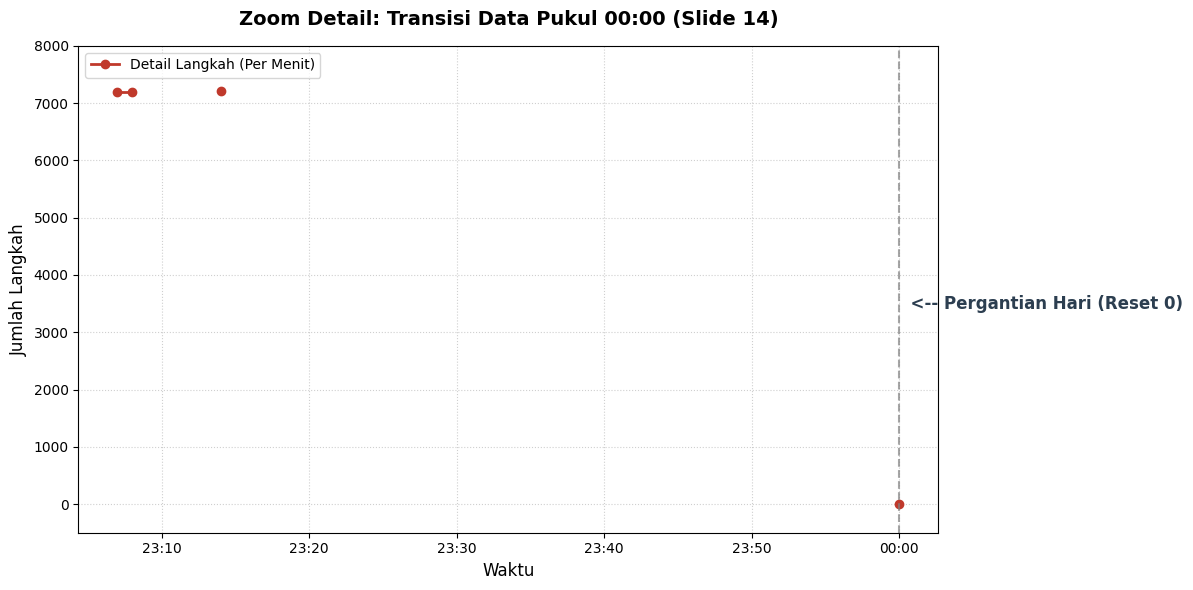

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

start_zoom = pd.Timestamp('2017-12-23 23:00:00') 
end_zoom = pd.Timestamp('2017-12-24 00:15:00')

df_zoom = df_clean[(df_clean['timestamp'] >= start_zoom) & 
                   (df_clean['timestamp'] <= end_zoom)]

ax.plot(df_zoom['timestamp'], df_zoom['steps'], 
        color='#c0392b', linewidth=2, marker='o', markersize=6, 
        label='Detail Langkah (Per Menit)')

midnight = pd.Timestamp('2017-12-24 00:00:00')
ax.axvline(midnight, color='gray', linestyle='--', alpha=0.7)

ax.set_ylim(-500, 8000)

ax.text(midnight, 3500, '  <-- Pergantian Hari (Reset 0)', 
        fontsize=12, color='#2c3e50', fontweight='bold', va='center')

ax.set_title('Zoom Detail: Transisi Data Pukul 00:00 (Slide 14)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Jumlah Langkah', fontsize=12)
ax.set_xlabel('Waktu', fontsize=12)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('zoom_detail_pukul_00.png', dpi=300, bbox_inches='tight')
plt.show()

## Kegagalan sinkronisasi Cloud

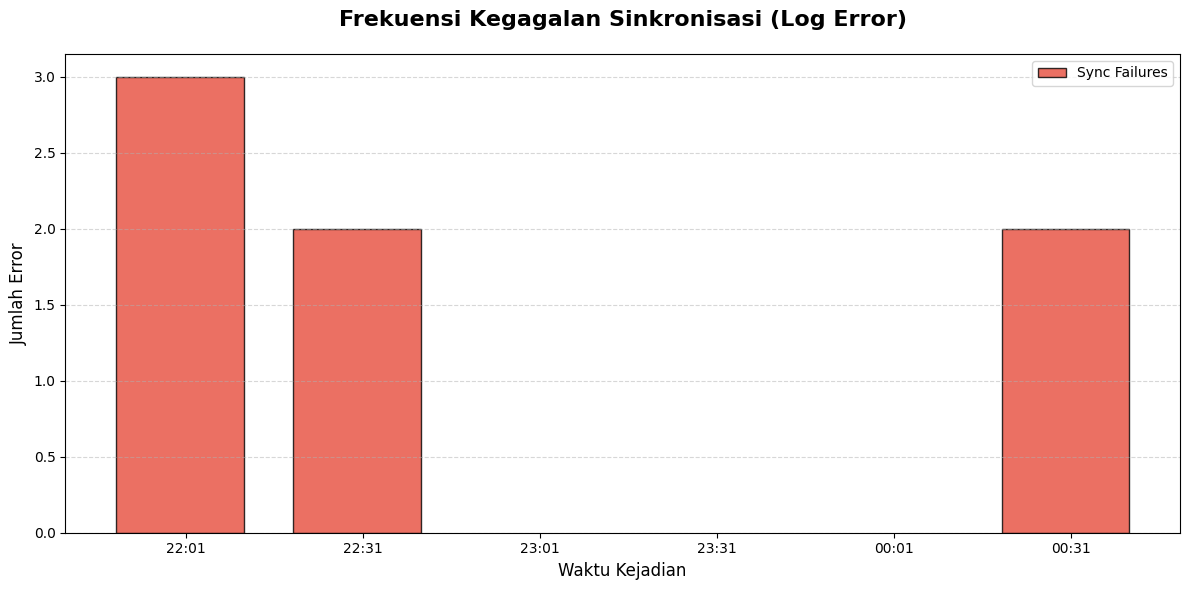

In [25]:
# 1. restore data yang sebelumnya hilang
# tulis ulang sampelnya
log_content = """
20171223-22:19:58:411|HiH_HiHealthBinder|30002312|insertHiHealthData() bulkSaveDetailHiHealthData fail errorCode = 4
20171223-22:19:58:428|HiH_HiBroadcastUtil|30002312|sendSyncFailedBroadcast
20171223-22:19:58:428|HiH_HiSyncControl|30002312|ifCanSync not! no cloud version
20171223-22:32:28:796|HiH_HiBroadcastUtil|30002312|sendSyncFailedBroadcast
20171223-22:32:28:806|HiH_HiSyncControl|30002312|ifCanSync not! no cloud version
20171224-00:32:28:806|HiH_HiBroadcastUtil|30002312|sendSyncFailedBroadcast
20171224-00:32:28:806|HiH_HiSyncControl|30002312|ifCanSync not! no cloud version
"""

with open('HealthApp_2k_Errors.log', 'w') as f:
    f.write(log_content.strip())

# 2. parsing khusus data error
filename = 'HealthApp_2k_Errors.log' # Gunakan file log asli Anda jika ada
data_fail = []
log_pattern = re.compile(r'^(\d{8}-\d{1,2}:\d{1,2}:\d{1,2}:\d{3})\|.*?\|.*?\|(.*)')

with open(filename, 'r') as file:
    for line in file:
        match = log_pattern.search(line)
        if match:
            timestamp_str = match.group(1)
            content = match.group(2).lower()
            
            # filter keyword yang berhubungan dengan error: 'fail', 'error', 'exception', 'no cloud'
            if 'fail' in content or 'error' in content or 'no cloud' in content:
                data_fail.append({'timestamp_raw': timestamp_str, 'message': 1}) # 1 = satu kejadian

# 3. visualisasi
if len(data_fail) > 0:
    df_fail = pd.DataFrame(data_fail)
    
    # convert waktu lagi
    df_fail['timestamp'] = pd.to_datetime(df_fail['timestamp_raw'], format='%Y%m%d-%H:%M:%S:%f')
    df_fail = df_fail.sort_values('timestamp')
    
    # resampling: hitung jumlah error setiap 30 menit
    df_fail = df_fail.set_index('timestamp')
    df_counts = df_fail.resample('30min').count().reset_index()
    
    # filter yang hanya terdapat error
    df_counts = df_counts[df_counts['message'] > 0]

    # bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.bar(df_counts['timestamp'], df_counts['message'], 
           width=0.015, color='#e74c3c', edgecolor='black', alpha=0.8, label='Sync Failures')

    ax.set_title('Frekuensi Kegagalan Sinkronisasi (Log Error)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Waktu Kejadian', fontsize=12)
    ax.set_ylabel('Jumlah Error', fontsize=12)
    
    # format jam
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    
    ax.grid(True, linestyle='--', alpha=0.5, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('frekuensi_kegagalan_sinkronisasi.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Tidak ditemukan data error")

## Analisis anomali

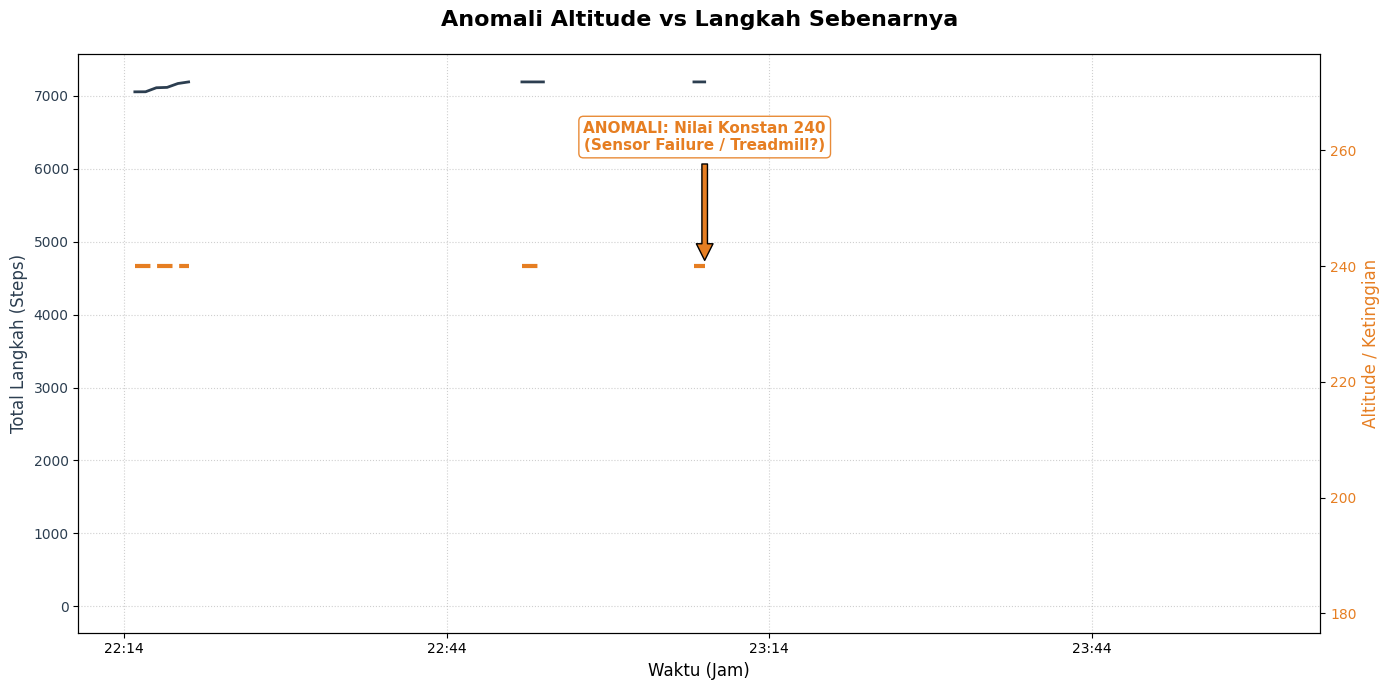

In [26]:
filename = 'HealthApp_2k.log'

data_list = []

log_pattern = re.compile(r'^(\d{8}-\d{1,2}:\d{1,2}:\d{1,2}:\d{3}).*REPORT : (\d+) \d+ \d+ (\d+)')

try:
    with open(filename, 'r') as file:
        for line in file:
            match = log_pattern.search(line)
            if match:
                timestamp_str = match.group(1)
                steps = int(match.group(2))
                altitude = int(match.group(3))
                data_list.append({
                    'timestamp_raw': timestamp_str,
                    'steps': steps,
                    'altitude': altitude
                })

    if len(data_list) > 0:
        df = pd.DataFrame(data_list)
        
        # convert timestamp lagi
        df['timestamp'] = pd.to_datetime(df['timestamp_raw'], format='%Y%m%d-%H:%M:%S:%f')
        df = df.drop(columns=['timestamp_raw'])
        df = df.sort_values('timestamp')
        
        # resample per menit lagi
        df = df.set_index('timestamp')
        df_clean = df.resample('1min').max().reset_index()

        # visualisasi
        fig, ax1 = plt.subplots(figsize=(14, 7))

        # plot di sumbu kiri untuk steps
        color_steps = '#2c3e50' # Biru Gelap
        ax1.set_xlabel('Waktu (Jam)', fontsize=12)
        ax1.set_ylabel('Total Langkah (Steps)', color=color_steps, fontsize=12)
        ax1.plot(df_clean['timestamp'], df_clean['steps'], 
                 color=color_steps, linewidth=2, label='Total Steps (Aktif)')
        ax1.tick_params(axis='y', labelcolor=color_steps)
        
        # format untuk sumbu X
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))

        # buat sumbu kanan untuk altitude
        ax2 = ax1.twinx()  
        color_alt = '#e67e22' # Oranye
        ax2.set_ylabel('Altitude / Ketinggian', color=color_alt, fontsize=12)
        
        # plot altitude dengan garis putus-putus
        ax2.plot(df_clean['timestamp'], df_clean['altitude'], 
                 color=color_alt, linewidth=3, linestyle='--', label='Altitude (Statis)')
        ax2.tick_params(axis='y', labelcolor=color_alt)
        
        if not df_clean['altitude'].dropna().empty:
            mean_alt = df_clean['altitude'].mean()
            ax2.set_ylim(mean_alt - 50, mean_alt + 50)

        mid_idx = len(df_clean) // 2
        mid_time = df_clean.iloc[mid_idx]['timestamp']
        
        ax2.annotate('ANOMALI: Nilai Konstan 240\n(Sensor Failure / Treadmill?)', 
                     xy=(mdates.date2num(mid_time), 240),
                     xytext=(mdates.date2num(mid_time), 260), # Geser teks ke atas sedikit
                     arrowprops=dict(facecolor=color_alt, shrink=0.05),
                     fontsize=11, color=color_alt, fontweight='bold', ha='center',
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color_alt, alpha=0.9))

        plt.title('Anomali Altitude vs Langkah Sebenarnya', 
                  fontsize=16, fontweight='bold', pad=20)
        ax1.grid(True, linestyle=':', alpha=0.6)
        
        plt.tight_layout()
        plt.savefig('anomali.png', dpi=300, bbox_inches='tight')
        plt.show()
        
    else:
        print("Tidak ada data yang terekstrak")

except FileNotFoundError:
    print("File log tidak ditemukan")